Sử dụng dataset kaggle.com/datasets/resulcaliskan/diamonds/versions/1 dự đoán giá của kim cương dựa trên các feature như:


| Thuộc tính  | Mô tả                                                                                                               |
| ----------- | ------------------------------------------------------------------------------------------------------------------- |
| **carat**   | Trọng lượng (carat) của viên kim cương                                                                              |
| **cut**     | Loại giác cắt của kim cương, ảnh hưởng đến độ sáng và độ lấp lánh (`Ideal`, `Premium`, `Very Good`, `Good`, `Fair`) |
| **color**   | Mức độ màu của kim cương, từ `D` đến `J` (`D`, `E`, `F`, `G`, `H`, `I`, `J`)                                        |
| **clarity** | Độ tinh khiết của kim cương (`I1`, `SI2`, `SI1`, `VS2`, `VS1`, `VVS2`, `VVS1`)                                      |
| **depth**   | Tỷ lệ độ sâu của viên kim cương                                                                                     |
| **table**   | Tỷ lệ mặt bàn — mặt phẳng lớn ở phía trên của viên kim cương, có thể nhìn thấy khi nhìn từ trên xuống               |
| **x**       | Chiều rộng của viên kim cương                                                                                       |
| **y**       | Chiều dài của viên kim cương                                                                                        |
| **z**       | Chiều cao của viên kim cương                                                                                        |
| **price**   | Giá của viên kim cương, tính bằng USD                                                                               |


Trong đó với logistic regression (dự đoán xem giá kim cương có hơn 5000$ hay không)

In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/resulcaliskan/diamonds/diamonds.csv


In [21]:
diamond = pd.read_csv('/kaggle/input/datasets/resulcaliskan/diamonds/diamonds.csv')
diamond.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [22]:
nan = pd.DataFrame({
    'column' : diamond.columns,
    'misin' : diamond.isna().sum().values
})
nan

,column,misin
0,carat,0
1,cut,0
2,color,0
3,clarity,0
4,depth,0
5,table,0
6,x,0
7,y,0
8,z,0
9,price,0


In [23]:
print(diamond.shape)

(53940, 10)


In [24]:
from sklearn.model_selection import train_test_split

X = diamond.drop(columns='price')
y = diamond['price']


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

categorical_features = ['cut', 'color', 'clarity']
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

**simple linear regression (chỉ dùng 1 feature)**

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

features = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']

results = []

for feature in features:

    # Chỉ lấy 1 feature
    X_train_feature = X_train[[feature]]
    X_val_feature = X_val[[feature]]
    X_test_feature = X_test[[feature]]

    # Nếu là categorical
    if feature in categorical_features:
        preprocessor = ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), [feature])
        ])

    # Nếu là numerical
    else:
        preprocessor = ColumnTransformer([
            ('num', 'passthrough', [feature])
        ])

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ])

    # Train
    pipeline.fit(X_train_feature, y_train)

    # Validation
    y_val_pred = pipeline.predict(X_val_feature)

    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_mae = mean_absolute_error(y_val, y_val_pred)

    # Test
    y_test_pred = pipeline.predict(X_test_feature)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)

    results.append({
        'Feature': feature,
        'Val_RMSE': val_rmse,
        'Val_MAE': val_mae,
        'Test_RMSE': test_rmse,
        'Test_MAE': test_mae
    })

metrics_simplelinear = pd.DataFrame(results)

metrics_simplelinear.sort_values('Val_RMSE')

,Feature,Val_RMSE,Val_MAE,Test_RMSE,Test_MAE
0,carat,1527.579151,1001.730113,1571.394046,1017.279371
7,y,1811.106645,1306.141997,1883.716812,1336.852221
6,x,1817.699181,1352.168747,1891.353945,1387.460807
8,z,1878.156898,1339.283606,1936.187017,1372.068123
2,color,3900.959858,2950.208644,3942.849741,2941.181809
3,clarity,3907.741804,2944.964714,3953.046244,2946.305879
5,table,3928.299491,2979.000578,3965.261383,2965.340924
1,cut,3940.687977,2987.868858,3974.154440,2974.001834
4,depth,3967.334445,3029.441796,4005.759075,3011.192449


**Linear Regression**

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

categorical_features = ['cut', 'color', 'clarity']
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

pipeline_linearRegression = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_linearRegression.fit(X_train, y_train)

y_val_pred_linear = pipeline_linearRegression.predict(X_val)
y_test_pred_linear = pipeline_linearRegression.predict(X_test)


from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

val_rmse_linear = np.sqrt(mean_squared_error(y_val, y_val_pred_linear))
val_mae_linear = mean_absolute_error(y_val, y_val_pred_linear)

test_rmse_linear = np.sqrt(mean_squared_error(y_test, y_test_pred_linear))
test_mae_linear = mean_absolute_error(y_test, y_test_pred_linear)

metrics_linearRegression = pd.DataFrame({
    'Metric': ['RMSE', 'MAE'],
    'Validation': [val_rmse_linear, val_mae_linear],
    'Test': [test_rmse_linear, test_mae_linear]
})

print(metrics_linearRegression)

  Metric   Validation         Test
0   RMSE  1111.566516  1158.374221
1    MAE   730.609071   743.693662


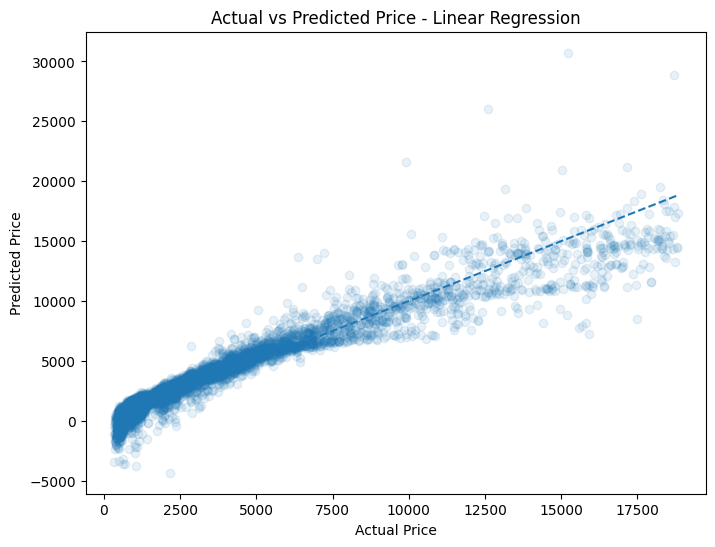

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_pred_linear, alpha=0.1)

# Đường dự đoán hoàn hảo y = x
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price - Linear Regression')
plt.show()

**POLY REGRESSION** thực nghiệm với từng degree

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

categorical_features = ['cut', 'color', 'clarity']
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

degrees = [2, 3, 4, 5, 6, 7, 8]

results = []

for degree in degrees:

    # Polynomial cho numeric features
    numeric_transformer = Pipeline([
        ('poly', PolynomialFeatures(
            degree=degree,
            include_bias=False
        ))
    ])

    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', numeric_transformer, numeric_features)
    ])

    pipeline_polyRegression = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ])

    # Train
    pipeline_polyRegression.fit(X_train, y_train)

    y_train_pred = pipeline_polyRegression.predict(X_train)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    
    # Predict
    y_val_pred = pipeline_polyRegression.predict(X_val)


    
    # Evaluation
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_mae = mean_absolute_error(y_val, y_val_pred)

    # Lưu kết quả
    results.append({
        'Degree': degree,
        'Validation RMSE': val_rmse,
        'Validation MAE': val_mae,
        'train RMSE' : train_rmse,
        'train MAE' : train_mae
    })

metrics_poly_valid = pd.DataFrame(results)

print(metrics_poly_valid)

   Degree  Validation RMSE  Validation MAE   train RMSE   train MAE
0       2      1017.916143      684.229498  1054.698516  694.272507
1       3      1023.052734      672.891158  1017.396344  671.761460
2       4      1559.097642      692.596422  1007.592933  666.527260
3       5      2189.294282      710.561498  1000.378259  661.929288
4       6      3814.730776      767.942667  1082.826425  672.486702
5       7      8570.773133      949.575540  1351.608135  778.958995
6       8      8521.143324      953.703147  1351.364472  778.907082


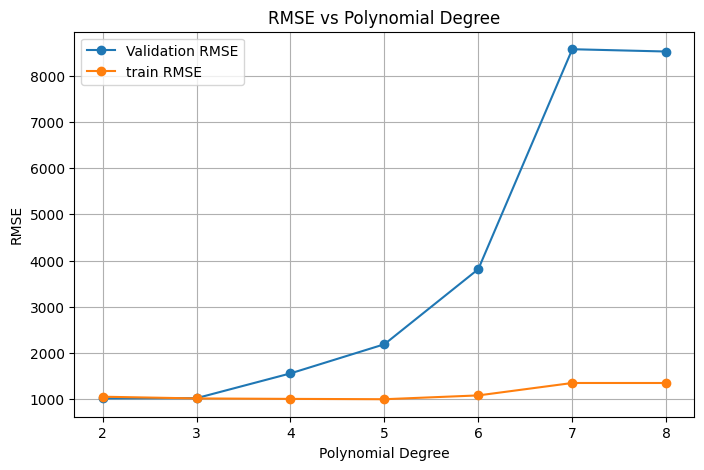

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    metrics_poly_valid['Degree'],
    metrics_poly_valid['Validation RMSE'],
    marker='o',
    label='Validation RMSE'
)

plt.plot(
    metrics_poly_valid['Degree'],
    metrics_poly_valid['train RMSE'],
    marker='o',
    label='train RMSE'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('RMSE vs Polynomial Degree')
plt.xticks(metrics_poly_valid['Degree'])
plt.legend()
plt.grid(True)

plt.show()

In [30]:
diamond['price'].unique()

array([ 326,  327,  334, ..., 2753, 2755, 2756])

**Logistic regress (predict price more than 10k ?)**

In [31]:
X_log = diamond.drop(columns='price')
y_log = (diamond['price'] > 5000).astype(int)

X_train_log, X_temp, y_train_log, y_temp = train_test_split(
    X_log, y_log,
    test_size=0.2,
    random_state=42,
    stratify=y_log
)

X_val_log, X_test_log, y_val_log, y_test_log = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_features = ['cut', 'color', 'clarity']
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')

pipeline_logisticRegression = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_logisticRegression.fit(X_train_log, y_train_log)

y_val_pred = pipeline_logisticRegression.predict(X_val_log)
y_test_pred = pipeline_logisticRegression.predict(X_test_log)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Validation:")
print("Accuracy:", accuracy_score(y_val_log, y_val_pred))
print("Precision:", precision_score(y_val_log, y_val_pred))
print("Recall:", recall_score(y_val_log, y_val_pred))
print("F1:", f1_score(y_val_log, y_val_pred))

# print("\nTest:")
# print("Accuracy:", accuracy_score(y_test, y_test_pred))
# print("Precision:", precision_score(y_test, y_test_pred))
# print("Recall:", recall_score(y_test, y_test_pred))
# print("F1:", f1_score(y_test, y_test_pred))

Validation:
Accuracy: 0.9710789766407119
Precision: 0.9445571331981069
Recall: 0.9496940856560163
F1: 0.9471186440677966


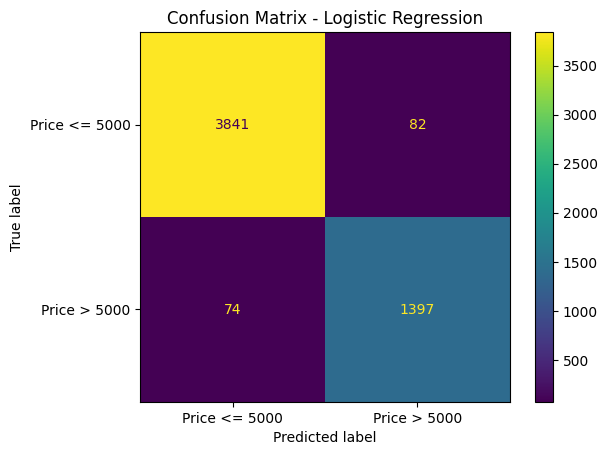

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_val_log,
    y_val_pred,
    display_labels=['Price <= 5000', 'Price > 5000']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [35]:
print(y_log.value_counts())
print(y_log.value_counts(normalize=True))

price
0    39226
1    14714
Name: count, dtype: int64
price
0    0.727215
1    0.272785
Name: proportion, dtype: float64


In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_val_prob = pipeline_logisticRegression.predict_proba(X_val_log)[:, 1]

print(classification_report(
    y_val_log,
    y_val_pred,
    target_names=['Price <= 5000', 'Price > 5000']
))

print("ROC-AUC:", roc_auc_score(y_val_log, y_val_prob))
print("PR-AUC:", average_precision_score(y_val_log, y_val_prob))


               precision    recall  f1-score   support

Price <= 5000       0.98      0.98      0.98      3923
 Price > 5000       0.94      0.95      0.95      1471

     accuracy                           0.97      5394
    macro avg       0.96      0.96      0.96      5394
 weighted avg       0.97      0.97      0.97      5394

ROC-AUC: 0.9966468731095338
PR-AUC: 0.9912184872471961
